# Two-terminal QH conductance with Kwant — cropped inner transport region, finite temperature

This notebook is identical in workflow to `qh_kwant_transport_two_terminal_JOBLIB.ipynb`, with one geometry optimization: the full Hartree potential is first reshaped under the source/drain mouths exactly as in the original v4 workflow, and **only afterwards** the reshaped outer regions are discarded.

For the left/right current-lead depth `source_drain_depth_nm`, the transport system retains only

```text
xmin + source_drain_depth_nm < x < xmax - source_drain_depth_nm
```

(equivalently, for a symmetric grid `-d + source_drain_depth_nm < x < d - source_drain_depth_nm`).

The source and drain are then attached to the new left/right boundaries of this reduced system. All other physics parameters, energy selection, magnetic-field treatment, JOBLIB sweep logic, observables, and saved output keys are unchanged.

Lead ordering used throughout:

```text
0 = source, left full-width lead
1 = drain, right full-width lead
```


## Finite-temperature modification

The geometry, Hartree-potential loading, cropping, lead construction, magnetic-field treatment,
disorder realization, and JOBLIB parallelization are unchanged.

For every magnetic-field frame, the Kwant system is built/finalized **once**. The zero-temperature
transmission is then evaluated at a small set of energies in

\[
E\in[\mu(B)-4k_BT,\ \mu(B)+4k_BT],
\]

and the finite-temperature two-terminal conductance is evaluated from the Fermi convolution

\[
G(B,T)=\int dE\,
\left[-\frac{\partial f(E-\mu,T)}{\partial E}\right]G_0(E,B).
\]

Because the numerical integral is truncated to \(\pm4k_BT\), the Fermi kernel is normalized over
the retained interval. The default uses only **9 energy points per B frame**.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
import multiprocessing

from module_kwant import *

## 1. Load the Hartree sweep

Set `SWEEP_DIR` to the directory containing subfolders with `metadata.json` and `data.npz`.
The potential key is usually `"U"`.

In [2]:
SWEEP_DIR = Path("data_sweep")
POTENTIAL_KEY = "U"

seq = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY,
    ground_each_frame=False,
)

print(seq.U_stack_meV.shape, "(nB, ny, nx)")
print("B range:", seq.B_values_T[0], "->", seq.B_values_T[-1], "T")
print("x range:", seq.x_nm.min(), "->", seq.x_nm.max(), "nm")
print("y range:", seq.y_nm.min(), "->", seq.y_nm.max(), "nm")
print("grid spacing a =", seq.a_nm, "nm")

(300, 151, 301) (nB, ny, nx)
B range: 0.6856013737026843 -> 4.0 T
x range: -1000.0 -> 1000.0 nm
y range: -500.0 -> 500.0 nm
grid spacing a = 6.666666666666667 nm


## 2. Define a two-terminal Hall bar

The source/drain potential reshaping is performed on the **full** Hartree grid first. A thin wrapper around the v4 preparation routine then removes the two reshaped outer sections before the Kwant builder is called. This keeps the original v4 logic intact while substantially reducing the number of lattice sites.


In [3]:
# Choose one representative frame for visualization/building.
FRAME_INDEX = 0  #min(101, len(seq.B_values_T) - 1)

# Lead-mouth parameters.
source_drain_depth_nm = 450.0     # reshaping depth for left/right current leads

lead_potential_meV = 0.0
smooth_nm = 1e1

lead_specs_2 = (
    LeadSpec(
        "source", "left",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
    LeadSpec(
        "drain", "right",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
)

#EFFECTIVE MASS SHOULD BE 0.067 BUT SINCE IN PREVIOUS SIMULATIONS I USED EB=1.76 * B I MUST USE THIS NEW ONE
cfg2 = DeviceConfig(
    m_eff=0.0658,
    g_factor=-0.0,
    norbs=1,
    disorder=DisorderConfig(amplitude_meV=1e-10, correlation_nm=30.0, seed=None),
    lead_specs=lead_specs_2,
    reshape_under_leads=True,
    lead_B_mode="zero",
)


# -------------------------------------------------------------------------
# Geometry optimization:
# 1) run the ORIGINAL v4 prepare_frame on the full Hartree grid, so the
#    source/drain mouths are reshaped exactly as before;
# 2) only afterwards discard the reshaped left/right sections;
# 3) make run_one_frame use this same cropped preparation also inside
#    JOBLIB worker processes.
# -------------------------------------------------------------------------

_prepare_frame_full = prepare_frame
_run_one_frame_full = run_one_frame


def crop_prepared_frame_x(prep, crop_depth_nm):
    """
    Return a copy of a v4 PreparedFrame restricted to the inner x interval

        xmin + crop_depth_nm < x < xmax - crop_depth_nm.

    The crop is applied to x_nm and to every prepared ndarray whose final
    spatial dimensions are (ny, nx), plus any 1D x-dependent array.

    This function deliberately acts AFTER the original v4 prepare_frame,
    hence U_for_transport_meV has already undergone the original lead-mouth
    reshaping before the outer regions are thrown away.
    """
    import copy
    import dataclasses

    x = np.asarray(prep.x_nm)
    y = np.asarray(prep.y_nm)
    nx = len(x)
    ny = len(y)

    xmin = float(x.min())
    xmax = float(x.max())

    x_left = xmin + float(crop_depth_nm)
    x_right = xmax - float(crop_depth_nm)

    keep_x = (x > x_left) & (x < x_right)

    if np.count_nonzero(keep_x) < 2:
        raise ValueError(
            "source_drain_depth_nm removes the whole transport region: "
            f"full x range = [{xmin}, {xmax}] nm, "
            f"requested retained interval = ({x_left}, {x_right}) nm."
        )

    def crop_value(name, value):
        # Coordinate arrays must be treated explicitly.
        if name == "x_nm":
            return np.asarray(value)[keep_x]

        if name == "y_nm":
            return np.asarray(value)   # NEVER crop y

        if not isinstance(value, np.ndarray):
            return value

        # Spatial maps: crop ONLY their x axis.
        if value.ndim >= 2 and value.shape[-2:] == (ny, nx):
            sl = [slice(None)] * value.ndim
            sl[-1] = keep_x
            return value[tuple(sl)]

        # 1D arrays known to live on x.
        # Only use this generic rule after excluding y_nm explicitly.
        if value.ndim == 1 and value.shape[0] == nx:
            return value[keep_x]

        return value

    if dataclasses.is_dataclass(prep):
        updates = {}
        for f in dataclasses.fields(prep):
            old = getattr(prep, f.name)
            new = crop_value(f.name, old)
            if new is not old:
                updates[f.name] = new
        cropped = dataclasses.replace(prep, **updates)
    else:
        # Fallback for a non-dataclass PreparedFrame implementation.
        cropped = copy.copy(prep)
        for name, old in vars(prep).items():
            new = crop_value(name, old)
            if new is not old:
                setattr(cropped, name, new)

    return cropped


def prepare_frame(seq, index, cfg):
    """Original v4 frame preparation followed by the inner-x crop."""
    prep_full = _prepare_frame_full(seq, index, cfg)
    return crop_prepared_frame_x(prep_full, source_drain_depth_nm)


def run_one_frame(*args, **kwargs):
    """
    Call the original v4 run_one_frame, but temporarily replace the module's
    prepare_frame by the cropped wrapper above.

    Doing the patch inside this function is intentional: JOBLIB/loky workers
    import the v4 module in separate processes, so each worker must activate
    the cropped preparation locally before running a frame.
    """
    module_globals = _run_one_frame_full.__globals__
    previous_prepare_frame = module_globals.get("prepare_frame")
    module_globals["prepare_frame"] = prepare_frame
    try:
        return _run_one_frame_full(*args, **kwargs)
    finally:
        module_globals["prepare_frame"] = previous_prepare_frame


# Prepare one frame through the NEW cropped path.
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

# Also prepare the corresponding full frame only for diagnostics.
prep2_full = _prepare_frame_full(seq, FRAME_INDEX, cfg2)

print("lead order:")
for i, spec in enumerate(cfg2.lead_specs):
    print(i, spec)
print("B =", prep2.B_T, "T")
print("t =", prep2.t_meV, "meV")
print("alpha =", prep2.alpha)
print("lB =", prep2.lB_nm, "nm")
print("full grid shape   =", prep2_full.U_for_transport_meV.shape)
print("cropped grid shape=", prep2.U_for_transport_meV.shape)
print(
    "x retained:",
    float(prep2.x_nm.min()), "->", float(prep2.x_nm.max()), "nm",
)
print(
    "site-count reduction factor ≈",
    prep2_full.U_for_transport_meV.size / prep2.U_for_transport_meV.size,
)


lead order:
0 LeadSpec(name='source', side='left', center_nm=None, width_nm=None, depth_nm=450.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
1 LeadSpec(name='drain', side='right', center_nm=None, width_nm=None, depth_nm=450.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
B = 0.6856013737026843 T
t = 13.028054361702127 meV
alpha = 0.007367896650409155
lB = 30.987778862221074 nm
full grid shape   = (151, 301)
cropped grid shape= (151, 165)
x retained: -546.6666666666666 -> 546.6666666666667 nm
site-count reduction factor ≈ 1.8242424242424242


## 2b. Finite-temperature transport parameters

Two conventions are supported:

- `TEMPERATURE_MODE = "ratio"` keeps \(k_BT/\hbar\omega_c\) fixed as \(B\) varies.
- `TEMPERATURE_MODE = "kelvin"` keeps the physical temperature fixed in Kelvin.

An odd number of energy points is used so that one sampled energy is exactly \(E=\mu\).
For a cheap first run, 7–9 points is a reasonable starting choice.


In [4]:
# -------------------------------------------------------------------------
# Finite-temperature settings
# -------------------------------------------------------------------------

KB_MEV_PER_K = 8.617333262e-2   # k_B in meV/K

TEMPERATURE_MODE = "kelvin"      # "ratio" or "kelvin"

# Used in ratio mode:
T_OVER_HBAR_OMEGA_C = 1e-3

# Used in kelvin mode:
TEMPERATURE_K = .2           # 50 mK

WINDOW_KBT = 4.5
N_ENERGY_POINTS = 15

if N_ENERGY_POINTS < 3 or N_ENERGY_POINTS % 2 == 0:
    raise ValueError("N_ENERGY_POINTS must be an odd integer >= 3.")


def kBT_meV_for_frame(prep):
    if TEMPERATURE_MODE == "ratio":
        return float(T_OVER_HBAR_OMEGA_C) * float(prep.omega_c_meV)

    if TEMPERATURE_MODE == "kelvin":
        return KB_MEV_PER_K * float(TEMPERATURE_K)

    raise ValueError("TEMPERATURE_MODE must be 'ratio' or 'kelvin'.")


def finite_T_energy_grid(mu_meV, kBT_meV, n_points=N_ENERGY_POINTS):
    if kBT_meV <= 0:
        return np.array([float(mu_meV)])

    offsets = np.linspace(
        -WINDOW_KBT,
        +WINDOW_KBT,
        int(n_points),
    )
    return float(mu_meV) + float(kBT_meV) * offsets


def minus_df_dE(E_meV, mu_meV, kBT_meV):
    # -df/dE = [4 kBT]^{-1} sech^2[(E-mu)/(2 kBT)]
    E_meV = np.asarray(E_meV, dtype=float)

    if kBT_meV <= 0:
        out = np.zeros_like(E_meV)
        out[np.argmin(np.abs(E_meV - float(mu_meV)))] = 1.0
        return out

    x = (E_meV - float(mu_meV)) / (2.0 * float(kBT_meV))
    return 1.0 / (4.0 * float(kBT_meV) * np.cosh(x)**2)


def finite_T_average(E_meV, values, mu_meV, kBT_meV):
    # Thermal convolution over the finite +/- WINDOW_KBT*kBT interval.
    # The kernel is renormalized on that interval so that a constant
    # G_0(E) remains unchanged by the truncation.
    E_meV = np.asarray(E_meV, dtype=float)
    values = np.asarray(values, dtype=float)

    if E_meV.size == 1 or kBT_meV <= 0:
        return float(values[0])

    kernel = minus_df_dE(E_meV, mu_meV, kBT_meV)
    norm = np.trapezoid(kernel, E_meV)

    if norm <= 0:
        raise RuntimeError("Non-positive Fermi-kernel normalization.")

    return float(np.trapezoid(values * kernel, E_meV) / norm)


print("Finite-temperature settings")
print("mode =", TEMPERATURE_MODE)
if TEMPERATURE_MODE == "ratio":
    print("kBT / hbar_omega_c =", T_OVER_HBAR_OMEGA_C)
else:
    print("T =", TEMPERATURE_K, "K")
print("window = +/-", WINDOW_KBT, "kBT")
print("energy points per B =", N_ENERGY_POINTS)


Finite-temperature settings
mode = kelvin
T = 0.2 K
window = +/- 4.5 kBT
energy points per B = 15


## 3. Visualize full reshaping and the cropped transport region

The left panel shows the full v4 reshaped potential and the two crop boundaries. The right panel is the actual reduced potential passed to Kwant. Thus the regions where the source/drain reshaping occurred are absent from the finite scattering region.


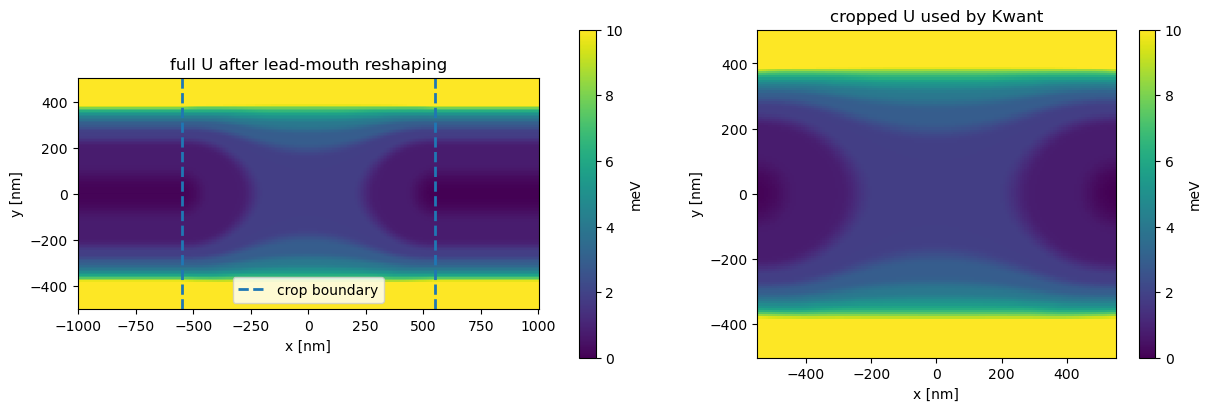

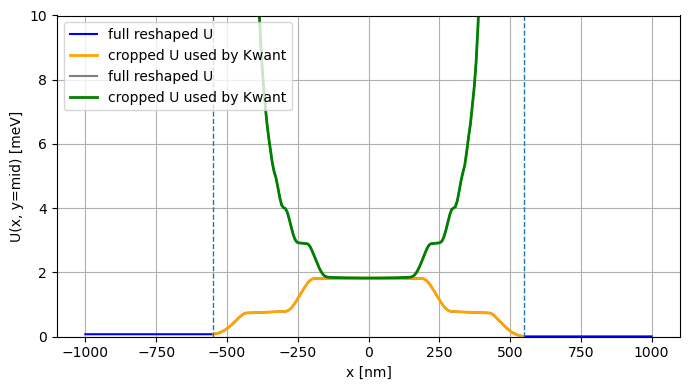

In [5]:
# Full frame after the ORIGINAL lead-mouth reshaping.
prep2_full = _prepare_frame_full(seq, FRAME_INDEX, cfg2)

xmin_full = float(prep2_full.x_nm.min())
xmax_full = float(prep2_full.x_nm.max())
x_left_crop = xmin_full + source_drain_depth_nm
x_right_crop = xmax_full - source_drain_depth_nm

# Cropped frame actually used for transport.
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im0 = axs[0].pcolormesh(
    prep2_full.x_nm,
    prep2_full.y_nm,
    prep2_full.U_for_transport_meV,
    shading="auto",
    vmin=0,
    vmax=10,
)
axs[0].axvline(x_left_crop, ls="--", lw=2, label="crop boundary")
axs[0].axvline(x_right_crop, ls="--", lw=2)
axs[0].set_aspect("equal")
axs[0].set_xlabel("x [nm]")
axs[0].set_ylabel("y [nm]")
axs[0].set_title("full U after lead-mouth reshaping")
axs[0].legend()
fig.colorbar(im0, ax=axs[0], label="meV")

im1 = axs[1].pcolormesh(
    prep2.x_nm,
    prep2.y_nm,
    prep2.U_for_transport_meV,
    shading="auto",
    vmin=0,
    vmax=10,
)
axs[1].set_aspect("equal")
axs[1].set_xlabel("x [nm]")
axs[1].set_ylabel("y [nm]")
axs[1].set_title("cropped U used by Kwant")
fig.colorbar(im1, ax=axs[1], label="meV")

plt.show()


# Mid-line comparison: the cropped curve is precisely the surviving interior
# of the already-reshaped full transport potential.
plt.figure(figsize=(7, 4))

y_mid_full = len(prep2_full.y_nm) // 2
y_mid_crop = len(prep2.y_nm) // 2

x_mid_full = len(prep2_full.x_nm) // 2
x_mid_crop = len(prep2.x_nm) // 2

plt.plot(
    prep2_full.x_nm,
    prep2_full.U_for_transport_meV[y_mid_full],
    color='blue',
    label="full reshaped U",
)
plt.plot(
    prep2.x_nm,
    prep2.U_for_transport_meV[y_mid_crop],
    lw=2,
    color='orange',
    label="cropped U used by Kwant",
)

plt.plot(
    prep2_full.y_nm,
    prep2_full.U_for_transport_meV[:,x_mid_full],
    color='grey',
    label="full reshaped U",
)
plt.plot(
    prep2.y_nm,
    prep2.U_for_transport_meV[:,x_mid_crop],
    lw=2,
    color='green',
    label="cropped U used by Kwant",
)

plt.axvline(x_left_crop, ls="--", lw=1)
plt.axvline(x_right_crop, ls="--", lw=1)

plt.ylim(0, 10)
plt.xlabel("x [nm]")
plt.ylabel("U(x, y=mid) [meV]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Build and inspect one reduced two-terminal Kwant system

The builder receives only the cropped `PreparedFrame`, so the finite scattering region contains no sites belonging to the discarded source/drain reshaping sections. The two full-width leads attach to the new left/right boundaries.


number of leads: 2


/opt/anaconda3/envs/kwant_env/lib/python3.10/site-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


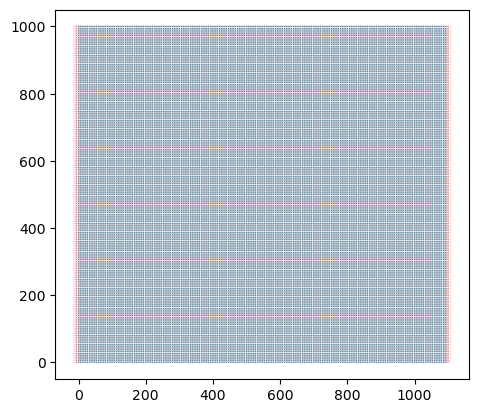

In [6]:
import kwant

builder2 = build_kwant_builder(prep2, cfg2)
fsyst2, phase_params2 = finalize_with_magnetic_field(
    builder2,
    prep2.B_T,
    len(cfg2.lead_specs),
    cfg2.lead_B_mode,
)

print("number of leads:", len(fsyst2.leads))
kwant.plot(fsyst2);

## 5. Run one two-terminal frame at finite temperature

The Hartree chemical potential is read from metadata exactly as in the original notebook.

For this representative frame, the cropped Kwant system is built/finalized once and the
transmission is evaluated over the thermal energy window. The cell reports both
\(G_0(E=\mu)\) and the finite-temperature convolution \(G(T)\).


B = 0.6856013737026843 T
mu = 12.661354299570272 meV
hbar omega_c = 1.20623788775559 meV
kBT = 0.017234666524000002 meV
T = 0.2 K
energy window = 12.583798300212273 -> 12.738910298928271 meV
number of energy points = 15

G(T=0, E=mu) [e^2/h] = 9.000337147988699
G(finite T)    [e^2/h] = 9.374458425890703

T matrix at E=mu:
[[0.     9.0003]
 [9.0003 0.    ]]


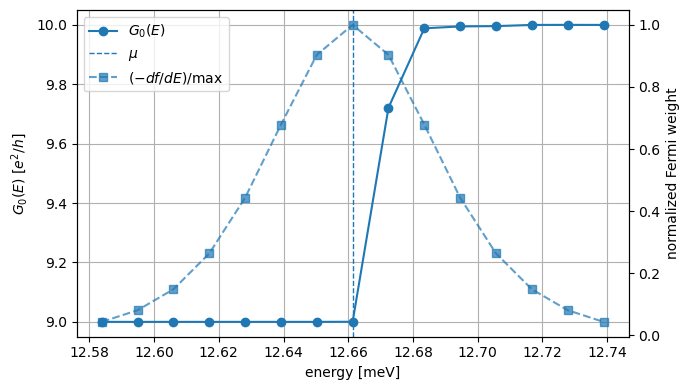

In [7]:
import kwant

selector = hartree_energy_selector(
    key_candidates=[
        "params.mu",
        "mu",
        "chemical_potential",
        "chemical_potential_meV",
        "fermi_energy",
        "fermi_energy_meV",
    ],
    unit="meV",
)

frame = seq.frame(FRAME_INDEX)
mu_frame = float(selector(frame))
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

ll_effective = np.around(mu_frame/(1.76*prep2.B_T)-.5, decimals=0)         # correct \mu by finite discretization error
JJ = 38.0998212/0.067/prep2.a_nm**2
EB = 1.76*prep2.B_T
dE = - EB**2/(32*JJ) * ( 2*ll_effective**2 + 2*ll_effective + 1 )*0
dE0 = - EB**2/(32*JJ) * ( 2*(ll_effective-1)**2 + 2*(ll_effective-1) + 1 )*0
mu_frame += (dE+dE0)/2


# Build/finalize only once for this B.
builder2 = build_kwant_builder(prep2, cfg2)
fsyst2, phase_params2 = finalize_with_magnetic_field(
    builder2,
    prep2.B_T,
    len(cfg2.lead_specs),
    cfg2.lead_B_mode,
)

kBT_frame = kBT_meV_for_frame(prep2)
T_kelvin_frame = kBT_frame / KB_MEV_PER_K

energy_grid_frame = finite_T_energy_grid(
    mu_frame,
    kBT_frame,
    N_ENERGY_POINTS,
)

G_energy_frame = []
T_matrices_frame = []

for E in energy_grid_frame:
    smat_E = kwant.smatrix(
        fsyst2,
        energy=float(E),
        params=phase_params2,
    )

    T_E = transmission_matrix(smat_E)
    G_E = two_terminal_conductance_e2h(
        T_E,
        source=0,
        drain=1,
    )

    T_matrices_frame.append(T_E)
    G_energy_frame.append(G_E)

G_energy_frame = np.asarray(G_energy_frame, dtype=float)

G_finiteT_frame = finite_T_average(
    energy_grid_frame,
    G_energy_frame,
    mu_frame,
    kBT_frame,
)

i_mu = int(np.argmin(np.abs(energy_grid_frame - mu_frame)))
G_T0_frame = float(G_energy_frame[i_mu])
T_mu_frame = T_matrices_frame[i_mu]

print("B =", prep2.B_T, "T")
print("mu =", mu_frame, "meV")
print("hbar omega_c =", prep2.omega_c_meV, "meV")
print("kBT =", kBT_frame, "meV")
print("T =", T_kelvin_frame, "K")
print(
    "energy window =",
    energy_grid_frame[0],
    "->",
    energy_grid_frame[-1],
    "meV",
)
print("number of energy points =", len(energy_grid_frame))
print()
print("G(T=0, E=mu) [e^2/h] =", G_T0_frame)
print("G(finite T)    [e^2/h] =", G_finiteT_frame)

np.set_printoptions(precision=4, suppress=True)
print()
print("T matrix at E=mu:")
print(T_mu_frame)

kernel_frame = minus_df_dE(
    energy_grid_frame,
    mu_frame,
    kBT_frame,
)

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(
    energy_grid_frame,
    G_energy_frame,
    "o-",
    label=r"$G_0(E)$",
)
ax1.axvline(mu_frame, ls="--", lw=1, label=r"$\mu$")
ax1.set_xlabel("energy [meV]")
ax1.set_ylabel(r"$G_0(E)$ [$e^2/h$]")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    energy_grid_frame,
    kernel_frame / kernel_frame.max(),
    "s--",
    alpha=0.7,
    label=r"$(-df/dE)/\max$",
)
ax2.set_ylabel("normalized Fermi weight")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()


## 6. Run the finite-temperature B sweep

Set `B_STRIDE = 1` for the full sweep.

Parallelization remains over magnetic-field frames. Inside each worker, the system is
built/finalized once and reused for all energies in the thermal window.


In [8]:
B_STRIDE = 1
indices = list(range(0, len(seq.B_values_T), B_STRIDE))
#indices = list(range(0, 75, B_STRIDE))

N_JOBS = max(1, multiprocessing.cpu_count() - 1)


def run_one_index_finite_T(i):
    import kwant

    frame_i = seq.frame(i)
    mu_i = float(selector(frame_i))

    # Same cropped potential preparation as in the T=0 notebook.
    prep_i = prepare_frame(seq, i, cfg2)
    
    EB = (1.76*prep_i.B_T)
    ll_effective = np.around(mu_i/EB - .5, decimals=0)         # correct \mu by finite discretization error
    JJ = 38.0998212/0.067/prep_i.a_nm**2
    dE = - EB**2/(32*JJ) * ( 2*ll_effective**2 + 2*ll_effective + 1 )*0
    dE0 = - EB**2/(32*JJ) * ( 2*(ll_effective-1)**2 + 2*(ll_effective-1) + 1 )*0
    mu_i += (dE+dE0)/2
    

    # Build/finalize exactly once for this B.
    builder_i = build_kwant_builder(prep_i, cfg2)
    fsyst_i, phase_params_i = finalize_with_magnetic_field(
        builder_i,
        prep_i.B_T,
        len(cfg2.lead_specs),
        cfg2.lead_B_mode,
    )

    kBT_i = kBT_meV_for_frame(prep_i)
    T_K_i = kBT_i / KB_MEV_PER_K

    energies_i = finite_T_energy_grid(
        mu_i,
        kBT_i,
        N_ENERGY_POINTS,
    )

    G_E_i = np.empty(len(energies_i), dtype=float)
    T_mu_i = None

    i_mu = int(np.argmin(np.abs(energies_i - mu_i)))

    for j, E in enumerate(energies_i):
        smat_E = kwant.smatrix(
            fsyst_i,
            energy=float(E),
            params=phase_params_i,
        )

        T_E = transmission_matrix(smat_E)

        G_E_i[j] = two_terminal_conductance_e2h(
            T_E,
            source=0,
            drain=1,
        )

        if j == i_mu:
            T_mu_i = np.asarray(T_E)

    G_T0_i = float(G_E_i[i_mu])

    G_finiteT_i = finite_T_average(
        energies_i,
        G_E_i,
        mu_i,
        kBT_i,
    )

    R_finiteT_i = (
        np.inf if G_finiteT_i == 0
        else 1.0 / G_finiteT_i
    )

    return {
        "index": i,
        "B_T": float(prep_i.B_T),
        "mu_meV": mu_i,
        "kBT_meV": float(kBT_i),
        "temperature_K": float(T_K_i),
        "G_T0_e2h": G_T0_i,
        "G_2terminal_e2h": float(G_finiteT_i),
        "R_2terminal_h_e2": float(R_finiteT_i),
        "energy_grid_meV": np.asarray(energies_i),
        "G_energy_e2h": np.asarray(G_E_i),
        "T_mu": T_mu_i,
        "G10_e2h": float(G_finiteT_i),
    }


results2 = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
    verbose=10,
)(
    delayed(run_one_index_finite_T)(i)
    for i in indices
)

results2 = sorted(results2, key=lambda r: r["index"])

B = np.array([r["B_T"] for r in results2])
mu = np.array([r["mu_meV"] for r in results2])

kBT_meV = np.array([r["kBT_meV"] for r in results2])
temperature_K = np.array([r["temperature_K"] for r in results2])

G_T0 = np.array([r["G_T0_e2h"] for r in results2])
G_2terminal = np.array([r["G_2terminal_e2h"] for r in results2])
R_2terminal = np.array([r["R_2terminal_h_e2"] for r in results2])
G10 = np.array([r["G10_e2h"] for r in results2])

energy_grids_meV = np.stack(
    [r["energy_grid_meV"] for r in results2],
    axis=0,
)

G_energy_e2h = np.stack(
    [r["G_energy_e2h"] for r in results2],
    axis=0,
)

print("done", len(results2), "frames")
print(
    "Kwant smatrix evaluations =",
    len(results2) * N_ENERGY_POINTS,
)


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   34.6s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  1.2min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  1.8min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  2.4min
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:  3.6min
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:  4.3min
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:  5.5min
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:  6.7min
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:  7.4min
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:  9.2min
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed: 10.4min
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed: 11.7min
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed: 13.4min
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed: 14.8min
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed: 16.6min
[Parallel(

done 300 frames
Kwant smatrix evaluations = 4500


## 7. Plot zero- and finite-temperature conductance


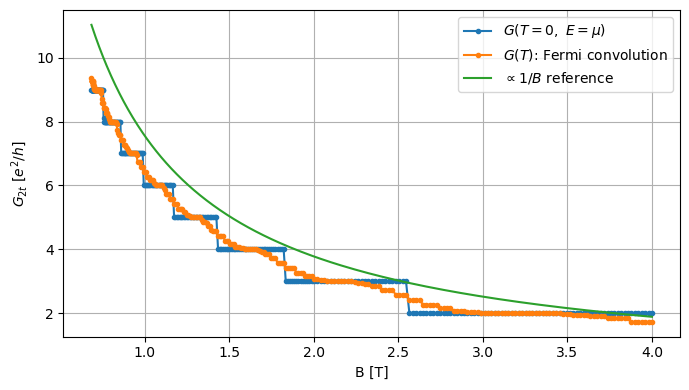

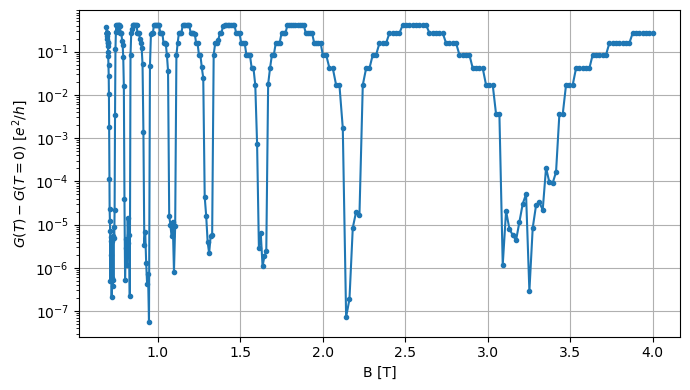

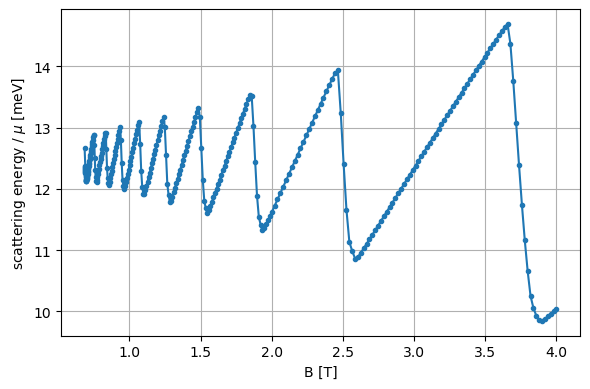

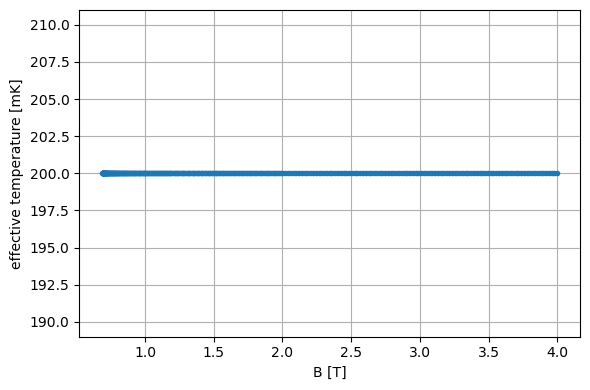

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    B,
    G_T0,
    marker="o",
    ms=3,
    label=r"$G(T=0,\ E=\mu)$",
)

plt.plot(
    B,
    G_2terminal,
    marker="o",
    ms=3,
    label=r"$G(T)$: Fermi convolution",
)
#plt.xlim(.5,1.2)
#plt.ylim(5.9,8.1)

plt.plot(
    B,
    1.85e-3 * 2*np.pi*25.5**2 / B,
    label=r"$\propto 1/B$ reference",
)

plt.xlabel("B [T]")
plt.ylabel(r"$G_{2t}$ [$e^2/h$]")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("G_comparison.pdf")

plt.show()


plt.figure(figsize=(7, 4))

plt.plot(
    B,
    abs(G_2terminal - G_T0),
    marker="o",
    ms=3,
)
plt.yscale('log')
plt.axhline(0.0, ls="--", lw=1)

plt.xlabel("B [T]")
plt.ylabel(r"$G(T)-G(T=0)$ [$e^2/h$]")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.plot(B, mu, marker="o", ms=3)
plt.xlabel("B [T]")
plt.ylabel(r"scattering energy / $\mu$ [meV]")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.plot(B, temperature_K * 1e3, marker="o", ms=3)
plt.xlabel("B [T]")
plt.ylabel("effective temperature [mK]")
plt.grid(True)
plt.tight_layout()
plt.show()


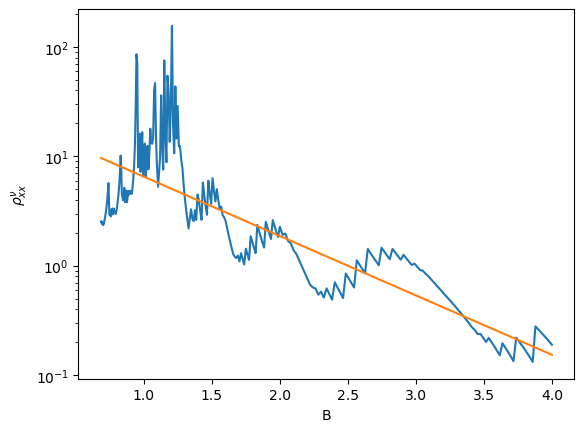

In [29]:
tttt = G_2terminal-1.85e-3 * 2*np.pi*25.5**2 / B + 1
rhoxxnu = 1/tttt - 1
plt.plot(B, abs(rhoxxnu) )
plt.plot( B, np.exp( -(B-2.5)/.8 ) )

plt.yscale('log')
plt.xlabel(r"B")
plt.ylabel(r"$\rho_{xx}^{\nu}$")

plt.savefig("scaling.pdf")

## 7b. Optional energy-grid convergence check

This is disabled by default because it performs additional Kwant calculations.
Enable it for one representative frame before a long production sweep if you want to verify that
9 points are sufficient.


In [10]:
RUN_GRID_CONVERGENCE_CHECK = False

if RUN_GRID_CONVERGENCE_CHECK:
    import kwant

    TEST_FRAME_INDEX = FRAME_INDEX
    TEST_N_POINTS = [5, 7, 9, 13, 17]

    frame_c = seq.frame(TEST_FRAME_INDEX)
    mu_c = float(selector(frame_c))
    prep_c = prepare_frame(seq, TEST_FRAME_INDEX, cfg2)

    builder_c = build_kwant_builder(prep_c, cfg2)
    fsyst_c, phase_params_c = finalize_with_magnetic_field(
        builder_c,
        prep_c.B_T,
        len(cfg2.lead_specs),
        cfg2.lead_B_mode,
    )

    kBT_c = kBT_meV_for_frame(prep_c)

    Gconv = []

    for npts in TEST_N_POINTS:
        E_c = finite_T_energy_grid(
            mu_c,
            kBT_c,
            n_points=npts,
        )

        G_c = []

        for E in E_c:
            smat_c = kwant.smatrix(
                fsyst_c,
                energy=float(E),
                params=phase_params_c,
            )
            T_c = transmission_matrix(smat_c)
            G_c.append(
                two_terminal_conductance_e2h(
                    T_c,
                    source=0,
                    drain=1,
                )
            )

        Gconv.append(
            finite_T_average(
                E_c,
                np.asarray(G_c),
                mu_c,
                kBT_c,
            )
        )

    print("B =", prep_c.B_T, "T")
    for npts, gval in zip(TEST_N_POINTS, Gconv):
        print(f"N_E={npts:2d}   G(T)={gval:.10f} e^2/h")

    plt.figure(figsize=(6, 4))
    plt.plot(TEST_N_POINTS, Gconv, "o-")
    plt.xlabel("number of energy points")
    plt.ylabel(r"$G(T)$ [$e^2/h$]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print(
        "Grid convergence check disabled. "
        "Set RUN_GRID_CONVERGENCE_CHECK=True to run it."
    )


Grid convergence check disabled. Set RUN_GRID_CONVERGENCE_CHECK=True to run it.


## 8. Save numerical results

The finite-temperature output includes the full small energy grid and \(G_0(E)\) used for each
convolution. `T_stack` remains available as the transmission matrix at exactly \(E=\mu\).


In [11]:
outfile = "two_terminal_transport_results_finite_T.npz"

T_mu_stack = np.stack(
    [r["T_mu"] for r in results2],
    axis=0,
)

np.savez(
    outfile,
    B=B,
    mu=mu,
    indices=np.array([r["index"] for r in results2]),

    kBT_meV=kBT_meV,
    temperature_K=temperature_K,
    temperature_mode=np.array(TEMPERATURE_MODE),
    T_over_hbar_omega_c=np.array(T_OVER_HBAR_OMEGA_C),
    window_kBT=np.array(WINDOW_KBT),
    n_energy_points=np.array(N_ENERGY_POINTS),

    G_T0=G_T0,
    G_2terminal=G_2terminal,
    R_2terminal=R_2terminal,
    G10=G10,

    energy_grids_meV=energy_grids_meV,
    G_energy_e2h=G_energy_e2h,

    T_mu_stack=T_mu_stack,
    T_stack=T_mu_stack,
)

print("saved", outfile)


saved two_terminal_transport_results_finite_T.npz
